<a href="https://colab.research.google.com/github/SiddhantUke/LangGraph/blob/main/Fault_Tolerance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q langgraph

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.checkpoint.memory import InMemorySaver
import time

In [6]:
## Define the class

class CrashState(TypedDict):
    input :str
    step1 :str
    step2 :str
    step3 :str

In [7]:
## Define steps

# def step_1(state)

In [8]:
# 2. Define steps

def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}


def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}


def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}




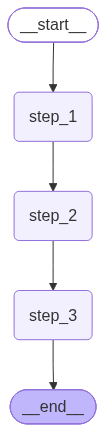

In [9]:
# 3. Build the graph

builder = StateGraph(CrashState)

builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()

## Build the graph

graph = builder.compile(checkpointer=checkpointer)
graph

In [10]:
checkpointer

In [11]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke(
        {"input": "start"},
        config={"configurable": {"thread_id": "thread-1"}}
    )

except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [12]:
graph.get_state({
    "configurable": {
        "thread_id": "thread-1"
    }
})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7780-67ce-8001-4743b465e4a0'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-27T05:52:46.789592+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7774-6839-8000-1922776f9698'}}, tasks=(PregelTask(id='4fee2cb4-83ca-9a69-e85d-b89d04ff8a5e', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [13]:
list(graph.get_state_history({
    "configurable": {
        "thread_id": "thread-1"
    }
}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7780-67ce-8001-4743b465e4a0'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-27T05:52:46.789592+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7774-6839-8000-1922776f9698'}}, tasks=(PregelTask(id='4fee2cb4-83ca-9a69-e85d-b89d04ff8a5e', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7774-6839-8000-1922776f9698'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-27T05:52:46.784688+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [15]:
final_state =  graph.invoke(
        None,
        config={"configurable": {"thread_id": "thread-1"}}
    )

⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed


In [16]:
list(graph.get_state_history({
    "configurable": {
        "thread_id": "thread-1"
    }
}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1dbb-90cf-6c9b-8003-f1b02a95385f'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-27T05:54:09.974157+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1dbb-90cc-67a5-8002-31be80a954d8'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1dbb-90cc-67a5-8002-31be80a954d8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-27T05:54:09.972788+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a1db8-7780-67ce-8001-4743b465e4a0'}}, tasks=(PregelTask(id='e74ae951-8460-9a73